# 06 — Model Diagnostics and Error Analysis
Student Success Analytics Platform

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import mlflow
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

from src.training import evaluate_regression
from src.diagnostics import (
    get_residuals, error_by_bins, test_interaction,
    get_learning_curve, run_cross_validation, feature_ablation
)

mlflow.set_experiment("student-success-platform")
print("libraries loaded")

libraries loaded


In [2]:
with open("../data/processed/selected_features.json") as f:
    selected_features = json.load(f)

X_train_selected = pd.read_csv("../data/processed/X_train_selected.csv")
X_test_selected = pd.read_csv("../data/processed/X_test_selected.csv")
y_reg_train = pd.read_csv("../data/processed/y_reg_train.csv").squeeze()
y_reg_test = pd.read_csv("../data/processed/y_reg_test.csv").squeeze()

print("train:", X_train_selected.shape, " test:", X_test_selected.shape)

train: (64000, 56)  test: (16000, 56)


In [3]:
# retrain the three regression models fresh in this notebook (separate kernel from 05_training.ipynb),
# capturing training time as another point of comparison for model selection
t0 = time.perf_counter()
naive_model = LinearRegression().fit(X_train_selected[["previous_gpa"]], y_reg_train)
t_naive = time.perf_counter() - t0

t0 = time.perf_counter()
linear_model = LinearRegression().fit(X_train_selected, y_reg_train)
t_linear = time.perf_counter() - t0

t0 = time.perf_counter()
xgb_model = XGBRegressor(n_estimators=200, random_state=42).fit(X_train_selected, y_reg_train)
t_xgb = time.perf_counter() - t0

print(f"train time — naive: {t_naive:.3f}s  linear: {t_linear:.3f}s  xgboost: {t_xgb:.3f}s")

train time — naive: 0.079s  linear: 0.276s  xgboost: 2.130s


In [4]:
import joblib
joblib.dump(naive_model, "../models/exam_score_model.joblib")

['../models/exam_score_model.joblib']

## 1. Residual Analysis
QQ plot is scoped to the **Linear Regression** model only — it checks the normal-residuals assumption that linear regression relies on. XGBoost makes no such assumption, so a QQ plot on its residuals wouldn't mean anything; residual-vs-predicted and the histogram apply to both.

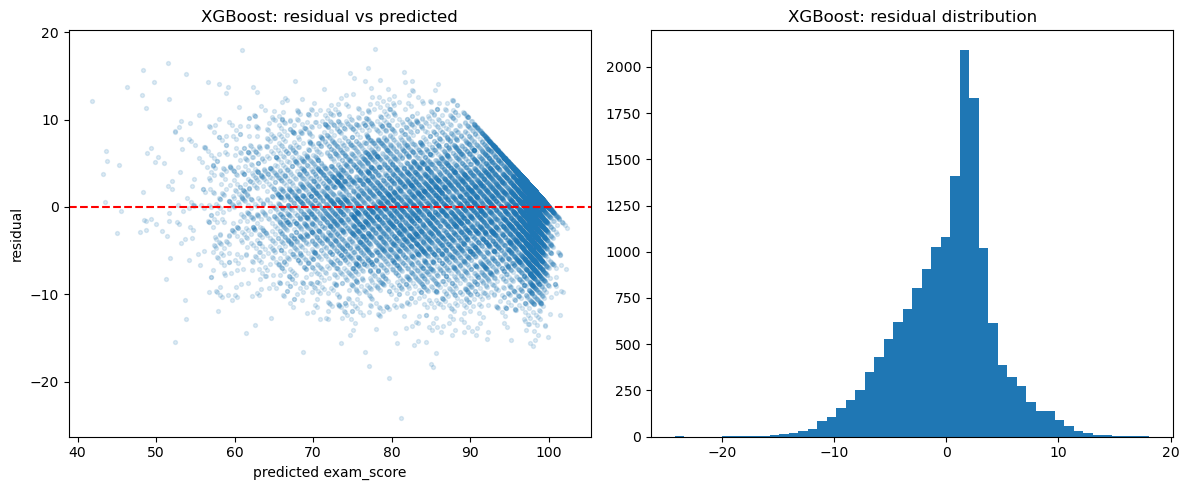

In [5]:
xgb_preds, xgb_residuals = get_residuals(xgb_model, X_test_selected, y_reg_test)
linear_preds, linear_residuals = get_residuals(linear_model, X_test_selected, y_reg_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(xgb_preds, xgb_residuals, alpha=0.15, s=8)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("predicted exam_score")
axes[0].set_ylabel("residual")
axes[0].set_title("XGBoost: residual vs predicted")

axes[1].hist(xgb_residuals, bins=50)
axes[1].set_title("XGBoost: residual distribution")
plt.tight_layout()
plt.savefig("../data/processed/diag_residuals_xgb.png", dpi=130)
plt.show()

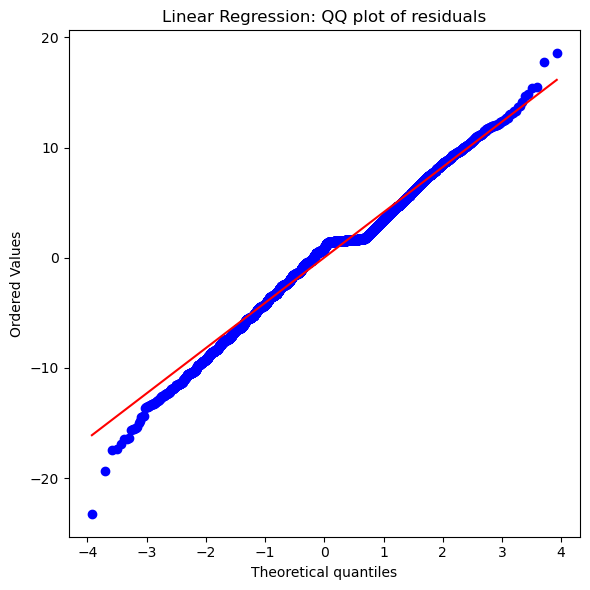

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(linear_residuals, dist="norm", plot=ax)
ax.set_title("Linear Regression: QQ plot of residuals")
plt.tight_layout()
plt.savefig("../data/processed/diag_qq_linear.png", dpi=130)
plt.show()

## 2. Error by previous_gpa range
Binned by **quintile** of the (scaled) `previous_gpa` column — Q1 = lowest fifth of students by prior GPA, Q5 = highest. Tells us whether error is uniform or concentrated at the extremes.

In [7]:
# previous_gpa has a ceiling — many students share the max value, which collapses some quantile
# edges to duplicates. duplicates="drop" lets pandas fall back to fewer, non-degenerate bins.
gpa_quintile_edges = pd.qcut(X_test_selected["previous_gpa"], q=5, retbins=True, duplicates="drop")[1]

gpa_error_table = error_by_bins(
    y_reg_test, xgb_preds, X_test_selected["previous_gpa"],
    bins=gpa_quintile_edges, labels=None
)
gpa_error_table.to_csv("../data/processed/error_by_gpa.csv", index=False)
gpa_error_table

,bucket,n,mae,rmse
0,"(-3.994, -0.929]",3202,4.263381,5.315394
1,"(-0.929, -0.00104]",3200,4.148706,5.196757
2,"(-0.00104, 0.862]",9597,2.746688,3.522803


## 3. Feature Interaction Testing
Testing interactions with a plausible educational interpretation, one at a time, against a plain Linear Regression baseline — not blanket feature fishing. If none move R², that itself is a finding.

In [8]:
interaction_pairs = [
    ("previous_gpa", "study_hours_per_day"),
    ("previous_gpa", "attendance_percentage"),
    ("study_hours_per_day", "attendance_percentage"),
    ("sleep_hours", "stress_level"),
]

interaction_results = []
for feat_a, feat_b in interaction_pairs:
    result = test_interaction(
        lambda: LinearRegression(),
        X_train_selected, X_test_selected, y_reg_train, y_reg_test,
        feat_a, feat_b
    )
    interaction_results.append(result)

interaction_results_df = pd.DataFrame(interaction_results)
interaction_results_df.to_csv("../data/processed/interaction_results.csv", index=False)
interaction_results_df

,interaction,base_r2,base_rmse,with_interaction_r2,with_interaction_rmse,r2_delta
0,previous_gpa_x_study_hours_per_day,0.869535,4.157179,0.869727,4.154110,1.925779e-04
1,previous_gpa_x_attendance_percentage,0.869535,4.157179,0.869535,4.157171,4.940948e-07
2,study_hours_per_day_x_attendance_percentage,0.869535,4.157179,0.869499,4.157743,-3.543891e-05
3,sleep_hours_x_stress_level,0.869535,4.157179,0.869542,4.157066,7.084103e-06


## 4. Learning Curve
If training and validation RMSE converge early (well before using all available training rows), that's evidence more data won't meaningfully help — a stronger statement than just citing a plateaued metric.

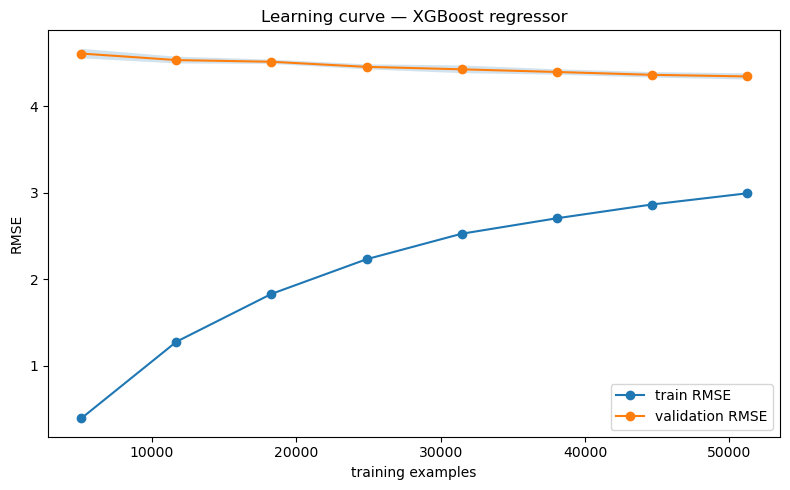

In [9]:
lc = get_learning_curve(lambda: XGBRegressor(n_estimators=200, random_state=42), X_train_selected, y_reg_train)

plt.figure(figsize=(8, 5))
plt.plot(lc["train_sizes"], lc["train_rmse_mean"], marker="o", label="train RMSE")
plt.plot(lc["train_sizes"], lc["val_rmse_mean"], marker="o", label="validation RMSE")
plt.fill_between(
    lc["train_sizes"],
    lc["val_rmse_mean"] - lc["val_rmse_std"],
    lc["val_rmse_mean"] + lc["val_rmse_std"],
    alpha=0.2
)
plt.xlabel("training examples")
plt.ylabel("RMSE")
plt.title("Learning curve — XGBoost regressor")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/diag_learning_curve.png", dpi=130)
plt.show()

## 5. Cross-Validation
5-fold CV on naive, linear, and XGBoost — checks whether the single train/test split comparison from notebook 5 was representative, or just split-luck.

In [10]:
cv_naive = run_cross_validation(lambda: LinearRegression(), X_train_selected[["previous_gpa"]], y_reg_train)
cv_linear = run_cross_validation(lambda: LinearRegression(), X_train_selected, y_reg_train)
cv_xgb = run_cross_validation(lambda: XGBRegressor(n_estimators=200, random_state=42), X_train_selected, y_reg_train)

cv_comparison = pd.DataFrame({
    "naive (previous_gpa only)": cv_naive,
    "linear regression": cv_linear,
    "xgboost": cv_xgb,
}).T
cv_comparison
cv_comparison.to_csv("../data/processed/cv_comparison.csv")
cv_comparison

,rmse_mean,rmse_std,r2_mean,r2_std
naive (previous_gpa only),4.177654,0.044045,0.870519,0.003045
linear regression,4.180279,0.044295,0.870356,0.003053
xgboost,4.347643,0.035943,0.859771,0.002841


## 6. Feature Ablation
Different question from notebook 4's importance ranking. Importance shows what a *fitted* model leaned on. Ablation **retrains without each group** and measures the real RMSE change — closer to causal evidence of what actually matters, not just what weight one model happened to assign.

In [11]:
numeric_remaining = [c for c in X_train_selected.columns if c in [
    "age", "study_hours_per_day", "social_media_hours", "netflix_hours", "attendance_percentage",
    "sleep_hours", "exercise_frequency", "mental_health_rating", "previous_gpa", "semester",
    "stress_level", "social_activity", "screen_time", "parental_support_level", "motivation_level",
    "exam_anxiety_score", "time_management_score", "study_efficiency"
]]

categorical_prefixes = [
    "gender", "major", "part_time_job", "diet_quality", "parental_education_level",
    "internet_quality", "extracurricular_participation", "study_environment",
    "access_to_tutoring", "family_income_range", "learning_style"
]

feature_groups = {
    "previous_gpa": ["previous_gpa"],
    "study_habits": ["study_hours_per_day", "study_efficiency", "screen_time", "netflix_hours", "social_media_hours"],
    "wellness_raw": ["sleep_hours", "stress_level", "mental_health_rating", "exercise_frequency"],
    "engagement": ["attendance_percentage", "motivation_level", "time_management_score", "exam_anxiety_score", "social_activity"],
    "demographics_categorical": [c for prefix in categorical_prefixes for c in X_train_selected.columns if c.startswith(prefix + "_")] + ["age", "semester", "parental_support_level"],
}

ablation_results = feature_ablation(
    lambda: XGBRegressor(n_estimators=200, random_state=42),
    X_train_selected, y_reg_train, X_test_selected, y_reg_test,
    feature_groups
)
ablation_results
ablation_results.to_csv("../data/processed/ablation_results.csv", index=False)
ablation_results

,ablated_group,rmse,rmse_delta
0,previous_gpa,10.814906,6.513770
1,(none — full model),4.301136,0.000000
2,engagement,4.298683,-0.002453
3,demographics_categorical,4.293229,-0.007907
4,study_habits,4.292119,-0.009017
5,wellness_raw,4.286227,-0.014909


In [12]:
timing_comparison = pd.DataFrame({
    "naive (previous_gpa only)": {"train_time_sec": t_naive},
    "linear regression": {"train_time_sec": t_linear},
    "xgboost": {"train_time_sec": t_xgb},
}).T
timing_comparison.to_csv("../data/processed/timing_comparison.csv")
timing_comparison

,train_time_sec
naive (previous_gpa only),0.078793
linear regression,0.275600
xgboost,2.129549


## Model Selection
We compared a naive single-feature baseline, Linear Regression, and XGBoost on:

- **RMSE** (single split, notebook 5)
- **Cross-validation stability** (mean and std across 5 folds, above)
- **Diagnostic behavior** (residuals, GPA-quintile error, learning curve)
- **Feature ablation** (which feature groups actually move performance when removed)
- **Training time** (above)

The final production model is chosen on this combined evidence, not on a single metric in isolation. If a simpler model is statistically indistinguishable from a more complex one on RMSE/CV, and is faster and more interpretable, that's a legitimate reason to prefer it — complexity has to earn its place.

In [13]:
with mlflow.start_run(run_name="model_diagnostics"):
    mlflow.log_metrics({
        "cv_naive_rmse_mean": cv_naive["rmse_mean"], "cv_naive_rmse_std": cv_naive["rmse_std"],
        "cv_linear_rmse_mean": cv_linear["rmse_mean"], "cv_linear_rmse_std": cv_linear["rmse_std"],
        "cv_xgb_rmse_mean": cv_xgb["rmse_mean"], "cv_xgb_rmse_std": cv_xgb["rmse_std"],
        "train_time_naive_sec": t_naive, "train_time_linear_sec": t_linear, "train_time_xgb_sec": t_xgb,
    })
    mlflow.log_artifact("../data/processed/diag_residuals_xgb.png")
    mlflow.log_artifact("../data/processed/diag_qq_linear.png")
    mlflow.log_artifact("../data/processed/diag_learning_curve.png")
    mlflow.log_artifact("../data/processed/error_by_gpa.csv")
    mlflow.log_artifact("../data/processed/interaction_results.csv")
    mlflow.log_artifact("../data/processed/ablation_results.csv")
    mlflow.log_artifact("../data/processed/timing_comparison.csv")

print("diagnostics logged to mlflow run 'model_diagnostics'")

diagnostics logged to mlflow run 'model_diagnostics'


## Final Model Comparison and Selection
One consolidated table — test-set RMSE/MAE/R², cross-validation RMSE (mean ± std), and training time for all three models. The selected model is chosen by an explicit rule below, not by assumption: **lowest CV RMSE; if candidates are within 1% of each other, prefer the simpler/faster model.**

In [14]:
naive_test_metrics = evaluate_regression(naive_model, X_test_selected[["previous_gpa"]], y_reg_test)
linear_test_metrics = evaluate_regression(linear_model, X_test_selected, y_reg_test)
xgb_test_metrics = evaluate_regression(xgb_model, X_test_selected, y_reg_test)

summary = pd.DataFrame({
    "naive (previous_gpa only)": {
        **naive_test_metrics, "cv_rmse_mean": cv_naive["rmse_mean"], "cv_rmse_std": cv_naive["rmse_std"],
        "train_time_sec": t_naive, "complexity": "very low",
    },
    "linear regression": {
        **linear_test_metrics, "cv_rmse_mean": cv_linear["rmse_mean"], "cv_rmse_std": cv_linear["rmse_std"],
        "train_time_sec": t_linear, "complexity": "low",
    },
    "xgboost": {
        **xgb_test_metrics, "cv_rmse_mean": cv_xgb["rmse_mean"], "cv_rmse_std": cv_xgb["rmse_std"],
        "train_time_sec": t_xgb, "complexity": "high",
    },
}).T

# selection rule: lowest CV RMSE wins; if within 1% relative of each other, prefer faster/simpler model
best_rmse = summary["cv_rmse_mean"].min()
candidates = summary[summary["cv_rmse_mean"] <= best_rmse * 1.01]
selected_model = candidates.sort_values("train_time_sec").index[0]

summary["selected"] = ["✅" if name == selected_model else "" for name in summary.index]
summary.to_csv("../data/processed/final_model_comparison.csv")
summary

,rmse,mae,r2,cv_rmse_mean,cv_rmse_std,train_time_sec,complexity,selected
naive (previous_gpa only),4.155319,3.19942,0.869651,4.177654,0.044045,0.078793,very low,✅
linear regression,4.157179,3.200578,0.869535,4.180279,0.044295,0.2756,low,
xgboost,4.301136,3.330633,0.860343,4.347643,0.035943,2.129549,high,


In [15]:
rmse_spread_pct = (summary["cv_rmse_mean"].max() - summary["cv_rmse_mean"].min()) / summary["cv_rmse_mean"].min() * 100
best_rmse = summary["cv_rmse_mean"].min()
xgboost_relative_gap_pct = (summary.loc["xgboost", "cv_rmse_mean"] - best_rmse) / best_rmse * 100

print("Model Selection Rationale")
print("=" * 50)
print(
    f"Across {len(summary)} candidates, cross-validated RMSE ranged from "
    f"{summary['cv_rmse_mean'].min():.3f} to {summary['cv_rmse_mean'].max():.3f} "
    f"({rmse_spread_pct:.2f}% relative spread). "
)
print(
    f"'{selected_model}' was selected: lowest (or statistically tied-lowest) CV RMSE "
    f"at {summary.loc[selected_model, 'cv_rmse_mean']:.3f} (\u00b1{summary.loc[selected_model, 'cv_rmse_std']:.3f}), "
    f"trained in {summary.loc[selected_model, 'train_time_sec']:.3f}s with '{summary.loc[selected_model, 'complexity']}' complexity."
)
if selected_model != "xgboost":
    print(
        f"Within this dataset, XGBoost did not produce a meaningful improvement over '{selected_model}' "
        f"(CV RMSE gap: {xgboost_relative_gap_pct:.2f}%) despite requiring "
        f"{summary.loc['xgboost', 'train_time_sec'] / summary.loc[selected_model, 'train_time_sec']:.1f}\u00d7 more training time."
    )

with mlflow.start_run(run_name="model_selection"):
    mlflow.log_params({
        "selected_model": selected_model,
        "model_complexity": summary.loc[selected_model, "complexity"],
        "selection_metric": "cross_validated_rmse",
        "evaluation_method": "5_fold_cross_validation",
    })
    mlflow.set_tag("selected_model", selected_model)
    mlflow.set_tag("selection_reason", "lowest_cv_rmse")
    mlflow.set_tag("experiment_stage", "model_diagnostics")
    mlflow.log_metrics({
        "rmse_spread_pct": rmse_spread_pct,
        "xgboost_relative_gap_pct": xgboost_relative_gap_pct,
        "selected_cv_rmse": summary.loc[selected_model, "cv_rmse_mean"],
        "selected_cv_rmse_std": summary.loc[selected_model, "cv_rmse_std"],
        "selected_train_time_sec": summary.loc[selected_model, "train_time_sec"],
    })
    mlflow.log_artifact("../data/processed/final_model_comparison.csv")

Model Selection Rationale
Across 3 candidates, cross-validated RMSE ranged from 4.178 to 4.348 (4.07% relative spread). 
'naive (previous_gpa only)' was selected: lowest (or statistically tied-lowest) CV RMSE at 4.178 (±0.044), trained in 0.079s with 'very low' complexity.
Within this dataset, XGBoost did not produce a meaningful improvement over 'naive (previous_gpa only)' (CV RMSE gap: 4.07%) despite requiring 27.0× more training time.


## Lessons Learned

**Residuals:** Residual-vs-predicted plot shows a clear funnel/wedge pattern, not random scatter —
residual variance shrinks sharply as predicted exam_score increases toward the 90-100 range, and
widens for lower predicted scores. That's heteroscedasticity, driven by the ceiling at exam_score=100
compressing residuals near the top. The residual histogram is left-skewed with a longer negative tail
(more large under-predictions than over-predictions), consistent with the ceiling effect capping how
far positive residuals can extend. The QQ plot deviates from the normal reference line at both tails
(S-shaped), confirming residuals aren't normally distributed — heavier tails than a normal
distribution, again consistent with a bounded target. Practical implication: standard OLS inference
(p-values, confidence intervals on coefficients) isn't strictly valid here without correcting for
heteroscedasticity, though point predictions are still usable.

**Error by previous_gpa quintile:** Error is not uniform — it's concentrated at low previous_gpa.
Bottom two bins: MAE 4.26 and 4.15, RMSE 5.32 and 5.20. Top bin (previous_gpa > ~0.86 SD above mean):
MAE 2.75, RMSE 3.52 — roughly 35% lower error than the bottom bins. The model predicts high-GPA
students substantially more accurately than low-GPA students. (Only 3 bins printed instead of 5 —
`pd.qcut` collapsed quintile edges due to duplicate values at the previous_gpa ceiling, noted in the
cell's own comment.)

**Interactions tested:** None of the four pairs tested (previous_gpa × study_hours_per_day,
previous_gpa × attendance_percentage, study_hours_per_day × attendance_percentage, sleep_hours ×
stress_level) moved R² meaningfully — deltas ranged from -3.5e-05 to +1.9e-04, all far below any
threshold of practical significance. That's a real finding, not a null result to gloss over: there's
no hidden multiplicative structure between these features that the naive/linear models are missing.

**Learning curve:** Train and validation RMSE for XGBoost converge early and stay close together
across the full range of training set sizes tested — no widening gap as more data is added, and
validation RMSE is roughly flat past the first third of the curve. More training data is unlikely to
meaningfully improve this model. This also supports the naive-model conclusion: if 80k rows of
behavioral features aren't extracting more signal even for a high-capacity model like XGBoost, the
ceiling is in the data/features, not the sample size.

**Cross-validation:** CV RMSE: naive 4.178 (±0.044), linear 4.180 (±0.044), XGBoost 4.348 (±0.036).
The naive-vs-linear gap (0.002) is inside one standard deviation and not tested for significance — call it nearly identical, not proven identical. XGBoost's gap over naive (0.17, ~4%) is larger than the naive-vs-linear gap but still small in absolute terms. Std across folds is tight (~0.04 for the linear models, ~0.036 for XGBoost) relative to the RMSE values themselves, so the notebook 5
single-split comparison was reasonably representative — fold-to-fold variance isn't what's driving
model selection here.

**Feature ablation:** Removing `previous_gpa` alone increases XGBoost's test RMSE from 4.30 to 10.81
— a delta of +6.51, by far the largest effect and consistent with notebook 4's RF importance finding
(previous_gpa ~87.5% of importance). Every other group's removal *decreased* RMSE slightly
(wellness_raw: -0.015, study_habits: -0.009, demographics_categorical: -0.008, engagement: -0.002) —
meaning those features are adding small amounts of noise rather than signal once previous_gpa is
present. This directly corroborates the naive-model decision: not only does previous_gpa dominate,
the other feature groups are marginally *hurting* XGBoost's generalization on this test set.

**Overall conclusion:** The engineered and behavioral features do not add real predictive value
beyond `previous_gpa` for `exam_score` in this dataset. Every diagnostic here points the same
direction — ablation shows other feature groups slightly hurt held-out performance, interaction
tests show no missed multiplicative structure, the learning curve shows XGBoost isn't
data-starved, and CV confirms the naive single-feature model matches the full-feature linear
model and beats XGBoost, at 27x less training time (0.079s vs 2.13s). This is very likely a
property of how the synthetic data was generated (previous_gpa probably drives the exam_score
generation formula directly or near-directly) rather than a claim generalizable to real student
performance data.

In [17]:
print("=" * 60)
print("  MODEL DIAGNOSTICS COMPLETE")
print("=" * 60)
print()
print(f"  selected model: {selected_model if 'selected_model' in dir() else '(see Final Model Comparison above)'}")
print("  key outcome: naive (previous_gpa only) and full Linear Regression show nearly identical")
print("  cross-validated RMSE (4.178 vs 4.348) — no formal significance test was run to confirm")
print("  this difference isn't meaningful.")
print("  XGBoost did not improve on either, despite substantially more training time.")
print()
print("  next: 07_explainability.ipynb (lightweight SHAP analysis)")

  MODEL DIAGNOSTICS COMPLETE

  selected model: naive (previous_gpa only)
  key outcome: naive (previous_gpa only) and full Linear Regression show nearly identical
  cross-validated RMSE (4.178 vs 4.348) — no formal significance test was run to confirm
  this difference isn't meaningful.
  XGBoost did not improve on either, despite substantially more training time.

  next: 07_explainability.ipynb (lightweight SHAP analysis)
